In [41]:
import numpy as np
from math import sqrt
from numpy.linalg import norm
from time import perf_counter
from scipy.special import erf
import matplotlib.pyplot as plt

# --- 1. CONFIGURATION ---

# Reproducibility
np.random.seed(42)

## Global constants and toggles
##DEFAULT_USE_LOWRANK = True        # Set True for RandSVD/HODLR experiments
##DEFAULT_RANK_K = 20               # Target rank for low-rank approximations
##DEFAULT_POWER_ITERS = 1           # Power iterations for randomized SVD

DEFAULT_RANK_K      = 20
DEFAULT_POWER_ITERS = 1
OLD_MIN_BLOCK       = 64

CHEB_P = 8         #Chebyshev interpolation order (rank)
MIN_BLOCK = 16     #Leaf size for HODLR recursion

# Choose Low-Rank Method (Change this in the experiment section)
# Options: 'ACA', 'RAND_SVD', 'HODLR'
#LOWRANK_METHOD = 'HODLR'


# --- 2. DATA GENERATION (Mixture of Gaussians) ---

rng = np.random.default_rng(42)
N = 100  # Reduced for quick testing

# Mixture on R_+ (positive axis): Two Gaussian components
x = np.abs(np.concatenate([
    rng.normal(loc=2.0, scale=0.4, size=N//2),
    rng.normal(loc=5.0, scale=0.7, size=N - N//2)
])).astype(float)
x.sort()

# Midpoints z_k between consecutive ordered samples; M = N-1
z = 0.5 * (x[:-1] + x[1:])
M = z.shape[0]

# Empirical CDF at midpoints: T_k = k/N, k = 1..N-1
T = np.arange(1, N) / N

# --- 3. GAUSSIAN KERNEL FUNCTIONS & MATRIX BUILDERS ---

SQRT2 = sqrt(2.0)
INV_SQRT_2PI = 1.0 / sqrt(2.0 * np.pi)

In [42]:
def generate_mixture_gaussian_data(N, seed=42):
    """Generate mixture of Gaussians data (using existing logic)."""
    rng = np.random.default_rng(seed)
    x = np.abs(np.concatenate([
        rng.normal(loc=2.0, scale=0.4, size=N//2),
        rng.normal(loc=5.0, scale=0.7, size=N - N//2)
    ])).astype(float)
    x.sort()
    return x

def generate_exponential_data(N, seed=42):
    """Generate exponential distribution data."""
    rng = np.random.default_rng(seed)
    x = rng.exponential(scale=2.0, size=N)
    x.sort()
    return x

def generate_uniform_data(N, seed=42):
    """Generate uniform distribution data."""
    rng = np.random.default_rng(seed)
    x = rng.uniform(low=0.0, high=10.0, size=N)
    x.sort()
    return x

def generate_lognormal_data(N, seed=42):
    """Generate log-normal distribution data."""
    rng = np.random.default_rng(seed)
    x = rng.lognormal(mean=1.0, sigma=0.5, size=N)
    x.sort()
    return x

def generate_beta_data(N, seed=42):
    """Generate beta distribution data."""
    rng = np.random.default_rng(seed)
    x = rng.beta(a=2.0, b=5.0, size=N) * 10.0  # Scale to [0, 10]
    x.sort()
    return x

In [43]:
def kappa(u):
    """Standard normal pdf φ(u). Vectorized."""
    return INV_SQRT_2PI * np.exp(-0.5 * u * u)

def K(u):
    """Standard normal cdf Φ(u) via erf. Vectorized."""
    return 0.5 * (1.0 + erf(u / SQRT2))


In [44]:
def build_Kmat(x, z, h):
    return K((z[:, None] - x[None, :]) / h[None, :])

def build_D(x, z, h):
    diff = z[:, None] - x[None, :]
    U    = diff / h[None, :]
    return -kappa(U) * (diff / (h[None, :] ** 2))

def randomized_svd(A, rank=32, q=1):
    """
    Randomized SVD for dense A (M x N).
    Returns U (M x r), S (r,), Vt (r x N) with r = min(rank, M, N).
    """
    M, N = A.shape
    r = int(min(rank, M, N))
    if r <= 0:
        return np.zeros((M,0)), np.zeros((0,)), np.zeros((0,N))

    Omega = np.random.randn(N, r)
    Y = A @ Omega                          # (M, r)
    for _ in range(q):
        Y = A @ (A.T @ Y)                  # power iterations

    Q, _ = np.linalg.qr(Y, mode='reduced') # (M, r)
    B = Q.T @ A                            # (r, N)
    Ub, S, Vt = np.linalg.svd(B, full_matrices=False)
    U = Q @ Ub                             # (M, r)
    return U, S, Vt

# ---------------- Rectangular Recursive HODLR (fixed signatures) ----------------
# Add more figures, error plots,
def HODLR_factor_recursive_rect(A, rank=None, q=1, min_block=64):
    m, n = A.shape
    if min(m, n) <= min_block:
        return {"type": "dense", "A": A.copy(), "m": m, "n": n}

    m1 = m // 2; m2 = m - m1
    n1 = n // 2; n2 = n - n1

    A11 = A[:m1, :n1]
    A12 = A[:m1, n1:]
    A21 = A[m1:, :n1]
    A22 = A[m1:, n1:]

    H11 = HODLR_factor_recursive_rect(A11, rank=rank, q=q, min_block=min_block)
    H22 = HODLR_factor_recursive_rect(A22, rank=rank, q=q, min_block=min_block)

    # ranks capped by local block size
    rank_k12 = rank if rank is not None else max(1, min( max(4, min(m1, n2)//10), min(m1, n2) ))
    rank_k21 = rank if rank is not None else max(1, min( max(4, min(m2, n1)//10), min(m2, n1) ))

    if A12.size == 0:
        U12 = np.zeros((m1, 0)); S12 = np.zeros((0,)); V12t = np.zeros((0, n2))
    else:
        U12, S12, V12t = randomized_svd(A12, rank=int(rank_k12), q=q)

    if A21.size == 0:
        U21 = np.zeros((m2, 0)); S21 = np.zeros((0,)); V21t = np.zeros((0, n1))
    else:
        U21, S21, V21t = randomized_svd(A21, rank=int(rank_k21), q=q)

    node = {
        "type": "node",
        "m": m, "n": n, "m1": m1, "m2": m2, "n1": n1, "n2": n2,
        "H11": H11, "H22": H22,
        "U12": U12, "S12": S12, "V12t": V12t,
        "U21": U21, "S21": S21, "V21t": V21t
    }
    return node



def HODLR_apply_row_sum_recursive_rect(H, N_total=None):
    """
    y = A @ 1_n for H representing an m x n matrix. Returns length-m vector.
    Signature kept as (H, N_total=None) so it matches earlier usage: APPLY_F(K_factors, N).
    """
    if H["type"] == "dense":
        return H["A"] @ np.ones(H["n"])

    m1 = H["m1"]; m2 = H["m2"]; n1 = H["n1"]; n2 = H["n2"]

    # y1
    y1_diag = HODLR_apply_row_sum_recursive_rect(H["H11"], N_total=n1)
    if H["V12t"].size == 0:
        y1_off = np.zeros(m1)
    else:
        s12 = H["V12t"] @ np.ones(n2)
        y1_off = H["U12"] @ (H["S12"] * s12)

    y1 = y1_diag + y1_off

    # y2
    if H["V21t"].size == 0:
        y2_off = np.zeros(m2)
    else:
        s21 = H["V21t"] @ np.ones(n1)
        y2_off = H["U21"] @ (H["S21"] * s21)

    y2_diag = HODLR_apply_row_sum_recursive_rect(H["H22"], N_total=n2)
    y2 = y2_off + y2_diag

    return np.concatenate([y1, y2])


def HODLR_apply_Dt_r_recursive_rect(H, r_vec, M_total=None):
    """
    g = A^T @ r_vec for H representing an m x n matrix.
    Signature intentionally (H, r_vec, M_total) to match your solve_kde call:
        APPLY_J(D_factors, r, M)
    M_total is accepted but not needed here (kept for API compatibility).
    Returns length-n vector.
    """
    if H["type"] == "dense":
        return H["A"].T @ r_vec

    m1 = H["m1"]; m2 = H["m2"]; n1 = H["n1"]; n2 = H["n2"]
    r1 = r_vec[:m1]; r2 = r_vec[m1:]

    # g1: length n1
    g1_diag = HODLR_apply_Dt_r_recursive_rect(H["H11"], r1, M_total=None)
    if H["U21"].size == 0:
        g1_off = np.zeros(n1)
    else:
        z21 = H["U21"].T @ r2
        g1_off = H["V21t"].T @ (H["S21"] * z21)
    g1 = g1_diag + g1_off

    # g2: length n2
    g2_diag = HODLR_apply_Dt_r_recursive_rect(H["H22"], r2, M_total=None)
    if H["U12"].size == 0:
        g2_off = np.zeros(n2)
    else:
        z12 = H["U12"].T @ r1
        g2_off = H["V12t"].T @ (H["S12"] * z12)
    g2 = g2_off + g2_diag

    return np.concatenate([g1, g2])




In [45]:
# ── NEW METHOD: Chebyshev-HODLR ──

def cheb_points(p):
    return np.cos((2*np.arange(p)+1)*np.pi/(2*p))

def scale11(x, a, b):
    return (2*x - (a+b)) / (b-a)

def chebyshev_polynomials(x, p):
    x = np.asarray(x)
    T = np.zeros((len(x), p))
    T[:,0] = 1.0
    if p > 1: T[:,1] = x
    for n in range(2, p):
        T[:,n] = 2*x*T[:,n-1] - T[:,n-2]
    return T

def hodlr_build_UV(z, x, p=8, min_block=16):
    def build(zi, xi):
        if len(zi)<=min_block or len(xi)<=min_block:
            return {'type':'dense','zi':zi,'xi':xi}
        zm=len(zi)//2; xm=len(xi)//2
        zi1,zi2=zi[:zm],zi[zm:]; xi1,xi2=xi[:xm],xi[xm:]
        def make_off(zii, xii):
            zb=z[zii]; xb=x[xii]
            az,bz=zb.min(),zb.max(); ax,bx=xb.min(),xb.max()
            if bz==az: bz+=1e-10
            if bx==ax: bx+=1e-10
            t = cheb_points(p)
            Tt  = chebyshev_polynomials(t, p)
            W   = (2/p) * np.where(np.arange(p)==0, 0.5, 1.0)
            WTt = W[:,None] * Tt.T
            Tz  = chebyshev_polynomials(scale11(zb,az,bz), p)
            Tx  = chebyshev_polynomials(scale11(xb,ax,bx), p)
            U   = Tz @ WTt
            V   = Tx @ WTt
            zc = 0.5*(bz-az)*t + 0.5*(bz+az)
            xc = 0.5*(bx-ax)*t + 0.5*(bx+ax)
            return {'type':'lowrank','U':U,'V':V,'zc':zc,'xc':xc,'xi':xii}
        return {'type':'node',
                'H11':build(zi1,xi1),'H22':build(zi2,xi2),
                'off12':make_off(zi1,xi2),'off21':make_off(zi2,xi1),
                'zi':zi,'xi':xi,'zm':zm}
    return build(np.arange(len(z)), np.arange(len(x)))

def hodlr_fill_S_K(node, z, x, h):
    if node['type']=='dense':
        zi,xi=node['zi'],node['xi']
        node['K']=K((z[zi][:,None]-x[xi][None,:])/h[xi][None,:]); return
    hodlr_fill_S_K(node['H11'],z,x,h); hodlr_fill_S_K(node['H22'],z,x,h)
    for off in [node['off12'],node['off21']]:
        off['S']=K((off['zc'][:,None]-off['xc'][None,:])/h[off['xi']].mean())

def hodlr_fill_S_D(node, z, x, h):
    if node['type']=='dense':
        zi,xi=node['zi'],node['xi']
        diff=z[zi][:,None]-x[xi][None,:]; hloc=h[xi][None,:]
        node['K']=-kappa(diff/hloc)*diff/(hloc**2); return
    hodlr_fill_S_D(node['H11'],z,x,h); hodlr_fill_S_D(node['H22'],z,x,h)
    for off in [node['off12'],node['off21']]:
        h_mean=h[off['xi']].mean(); diff=off['zc'][:,None]-off['xc'][None,:]
        off['S']=-kappa(diff/h_mean)*diff/(h_mean**2)

def hodlr_matvec(node, v):
    if node['type']=='dense': return node['K'] @ v[node['xi']]
    zm=node['zm']; out=np.zeros(len(node['zi']))
    out[:zm]+=hodlr_matvec(node['H11'],v); out[zm:]+=hodlr_matvec(node['H22'],v)
    off12=node['off12']
    out[:zm]+=off12['U']@(off12['S']@(off12['V'].T@v[off12['xi']]))
    off21=node['off21']
    out[zm:]+=off21['U']@(off21['S']@(off21['V'].T@v[off21['xi']]))
    return out

def hodlr_rmatvec(node, r):
    N_total = node['xi'][-1]+1
    def recurse(nd, r_sub):
        if nd['type']=='dense':
            g=np.zeros(N_total); g[nd['xi']]+=nd['K'].T@r_sub; return g
        zm=nd['zm']; r1,r2=r_sub[:zm],r_sub[zm:]
        g=recurse(nd['H11'],r1)+recurse(nd['H22'],r2)
        off12=nd['off12']; g[off12['xi']]+=off12['V']@(off12['S'].T@(off12['U'].T@r1))
        off21=nd['off21']; g[off21['xi']]+=off21['V']@(off21['S'].T@(off21['U'].T@r2))
        return g
    return recurse(node, r)

In [46]:
from time import perf_counter
import numpy as np
from numpy.linalg import norm


def solve_kde_enhanced(x, z, T, *,
                       method='DENSE',          # 'DENSE' | 'RAND_SVD_HODLR' | 'CHEB_HODLR'
                       p=8,                     # Cheb order OR SVD rank
                       min_block=None,
                       eta=0.5,
                       max_iters=100,
                       tol=1e-6,
                       verbose=False):

    N = len(x)
    if min_block is None:
        min_block = 64 if method == 'RAND_SVD_HODLR' else 16

    time_build = 0.0
    time_grad  = 0.0


    # Build phase (only once before GD)

    if method == 'CHEB_HODLR':
        t0 = perf_counter()
        tree = hodlr_build_UV(z, x, p=p, min_block=min_block)
        time_build = perf_counter() - t0

    # Helper functions
    def _F_hat(h):

        if method == 'DENSE':
            return K((z[:, None] - x[None, :]) / h[None, :]) @ np.ones(N) / N


        elif method == 'RAND_SVD_HODLR':
            Kmat = build_Kmat(x, z, h)
            Kh   = HODLR_factor_recursive_rect(Kmat, rank=p, min_block=min_block)
            return HODLR_apply_row_sum_recursive_rect(Kh, N) / N


        elif method == 'CHEB_HODLR':
            hodlr_fill_S_K(tree, z, x, h)
            return hodlr_matvec(tree, np.ones(N)) / N


    def _grad_J(h):

        r = _F_hat(h) - T
        J_curr = float(r @ r)

        if method == 'DENSE':
            diff  = z[:, None] - x[None, :]
            U_arg = diff / h[None, :]
            g = (2.0 / N) * (-kappa(U_arg) * diff / (h[None, :] ** 2)).T @ r


        elif method == 'RAND_SVD_HODLR':
            Dmat = build_D(x, z, h)
            Dh   = HODLR_factor_recursive_rect(Dmat, rank=p, min_block=min_block)
            g = (2.0 / N) * HODLR_apply_Dt_r_recursive_rect(Dh, r, len(z))


        elif method == 'CHEB_HODLR':
            hodlr_fill_S_D(tree, z, x, h)
            g = (2.0 / N) * hodlr_rmatvec(tree, r)
        return g, J_curr


    def _J(alpha):
        h_local = np.exp(alpha)
        r_local = _F_hat(h_local) - T
        return float(r_local @ r_local)


    # Initialization
    data_span = x.max() - x.min()
    h = np.full(N, max(0.2 * data_span / (N ** 0.2), 1e-3))
    alpha = np.log(h)

    J_hist = []
    t_hist = []
    grad_norm_hist = []

    J0 = _J(alpha)

    J_hist.append(J0)
    t_hist.append(0.0)
    grad_norm_hist.append(0.0)

    if verbose:
        print(f'[{method}] J0 = {J0:.6f}')

    # Gradient descent
    t0_grad = perf_counter()

    for k in range(max_iters):
        h = np.exp(alpha)
        grad_h, J_curr = _grad_J(h)
        grad_alpha = grad_h * h
        grad_norm = norm(grad_alpha)

        alpha_new = np.clip(
            alpha - eta * grad_alpha,
            np.log(1e-3),
            np.log(5.0 * data_span)
        )

        J_new = _J(alpha_new)

        tries = 0

        while J_new > J_curr and tries < 10:

            eta *= 0.5
            alpha_new = np.clip(
                alpha - eta * grad_alpha,
                np.log(1e-3),
                np.log(5.0 * data_span)
            )
            J_new = _J(alpha_new)
            tries += 1

        alpha = alpha_new

        J_hist.append(J_new)
        t_hist.append(perf_counter() - t0_grad)
        grad_norm_hist.append(grad_norm)

        if verbose and (k + 1) % 20 == 0:
            print(f'  iter {k+1}: J={J_new:.6f} ||g||={grad_norm:.2e}')

        if grad_norm < tol:
            if verbose:
                print(f'  Converged at iter {k+1}')
            break

    time_grad = perf_counter() - t0_grad

    # Final bandwidth
    h_opt = np.exp(alpha)


    return h_opt, {
        'method': method,
        'p': p,
        'min_block': min_block,
        'J_final': J_hist[-1],
        'J_initial': J_hist[0],
        'total_time': time_build + time_grad,
        'time_build': time_build,
        'time_grad': time_grad,
        'iterations': len(J_hist) - 1,
        'final_grad_norm': grad_norm_hist[-1],
        'J_hist': J_hist,
        't_hist': t_hist,
        'grad_norm_hist': grad_norm_hist,
        'x': x,
        'h_stats': (
            float(h_opt.min()),
            float(np.median(h_opt)),
            float(h_opt.max())
        )
    }

In [47]:
def true_mixture(u, SQRT2):
    """True mixture density from which data was drawn."""
    INV_SQRT_2PI = 1.0 / sqrt(2.0 * np.pi)

    def component_pdf(u, loc, scale):
        u_scaled = (u - loc) / scale
        return (1/scale) * INV_SQRT_2PI * np.exp(-0.5 * u_scaled**2)

    f1 = component_pdf(u, loc=2.0, scale=0.4)
    f2 = component_pdf(u, loc=5.0, scale=0.7)

    result = 0.5 * f1 + 0.5 * f2
    result[u < 0] = 0
    return result

def kde_estimate(u, x, h):
    """Evaluate KDE at points u using sample points x and per-sample bandwidths h."""
    U = (u[:, None] - x[None, :]) / h[None, :]
    return np.mean(kappa(U) / h[None, :], axis=1)

def kde_true_error(u, x, h, SQRT2):
    """
    Compute L2 error between true mixture density and KDE estimate.
    """

    # true density
    f_true = true_mixture(u, SQRT2)

    # KDE estimate
    f_kde = kde_estimate(u, x, h)

    # L2 error
    error = np.sqrt(np.mean((f_true - f_kde)**2))

    return error


In [48]:
def run_scaling_experiment(N_values=[500, 1000, 2000, 4000],
                           ranks=[5, 8],
                           min_blocks=[16],
                           distributions=['mixture_gaussian']):

    data_generators = {
        'mixture_gaussian': generate_mixture_gaussian_data,
        'exponential':      generate_exponential_data,
        'uniform':          generate_uniform_data,
        'lognormal':        generate_lognormal_data,
        'beta':             generate_beta_data,
    }

    results = {}

    print("\n" + "="*80)
    print("COMPREHENSIVE COMPARISON: DENSE vs RAND_SVD_HODLR vs CHEB_HODLR")
    print("="*80)

    for dist_name in distributions:
        print(f"\n=== {dist_name.upper()} ===")
        results[dist_name] = {'dense': [], 'rand_svd': {}, 'hodlr': {}}
        generate_data = data_generators[dist_name]

        for N in N_values:
            print(f"  N = {N}")
            x = generate_data(N)
            z = 0.5 * (x[:-1] + x[1:])
            T = np.arange(1, N) / N

            # Dense baseline
            print("    [DENSE] ...", end=" ", flush=True)
            _, m_dense = solve_kde_enhanced(x, z, T, method='DENSE',
                max_iters=100, tol=1e-6, verbose=False)
            results[dist_name]['dense'].append(m_dense)
            print(f"J={m_dense['J_final']:.4f}  t={m_dense['total_time']:.2f}s")

            for rank in ranks:
                for min_block in min_blocks:
                    key = f'p{rank}_b{min_block}'

                    # RandSVD-HODLR (only for N <= 2000 — too slow at large N)
                    if N <= 2000:
                        if key not in results[dist_name]['rand_svd']:
                            results[dist_name]['rand_svd'][key] = []
                        print(f"    [RAND_SVD_HODLR {key}] ...", end=" ", flush=True)
                        _, m_rand = solve_kde_enhanced(x, z, T,
                            method='RAND_SVD_HODLR', p=rank, min_block=min_block,
                            max_iters=100, tol=1e-6, verbose=False)
                        results[dist_name]['rand_svd'][key].append(m_rand)
                        print(f"J={m_rand['J_final']:.4f}  t={m_rand['total_time']:.2f}s")

                    # Cheb-HODLR
                    if key not in results[dist_name]['hodlr']:
                        results[dist_name]['hodlr'][key] = []
                    print(f"    [CHEB_HODLR {key}] ...", end=" ", flush=True)
                    _, m_hodlr = solve_kde_enhanced(x, z, T,
                        method='CHEB_HODLR', p=rank, min_block=min_block,
                        max_iters=100, tol=1e-6, verbose=False)
                    results[dist_name]['hodlr'][key].append(m_hodlr)
                    print(f"J={m_hodlr['J_final']:.4f}  t={m_hodlr['total_time']:.2f}s")

    return results, N_values

In [49]:
def create_comprehensive_plots(results, N_values, save_plots=True):
    '''Overview plots showing runtime scaling, build vs gradient time, KDE error, and loss convergence.'''

    distributions = list(results.keys())
    n_dists = len(distributions)

    fig = plt.figure(figsize=(14, 8*n_dists))
    u_eval = np.linspace(0,8,1500)

    for idx, dist_name in enumerate(distributions):

        dist_results = results[dist_name]

        # ---------- Runtime scaling ----------
        ax = plt.subplot(n_dists*2,2,idx*4+1)

        dense_times=[m['total_time'] for m in dist_results['dense']]
        ax.loglog(N_values,dense_times,'ko-',lw=3,label='Dense')

        for key,rand_list in dist_results['rand_svd'].items():
            rand_N=N_values[:len(rand_list)]
            ax.loglog(rand_N,[m['total_time'] for m in rand_list],'s--',label=f'RandSVD {key}')

        for key,cheb_list in dist_results['hodlr'].items():
            ax.loglog(N_values,[m['total_time'] for m in cheb_list],'^-',label=f'Cheb {key}')

        ax.set_title(f"Total Runtime vs N — {dist_name}")
        ax.set_xlabel("N")
        ax.set_ylabel("Runtime (s)")
        ax.grid(True)
        ax.legend()

        # ---------- KDE Error ----------
        ax = plt.subplot(n_dists*2,2,idx*4+3)

        if dist_name=='mixture_gaussian':

            true_vals=true_mixture(u_eval,SQRT2)

            errs=[]
            for i,N in enumerate(N_values):

                x=dist_results['dense'][i]['x']
                h=np.full_like(x,dist_results['dense'][i]['h_stats'][1])

                kde=kde_estimate(u_eval,x,h)
                err=np.sqrt(np.mean((true_vals-kde)**2))
                errs.append(err)

            ax.loglog(N_values,errs,'ko-',label='Dense')
            for key, rand_list in dist_results['rand_svd'].items():
            
                errs=[]
                rand_N=N_values[:len(rand_list)]
            
                for i in range(len(rand_list)):
            
                    x=rand_list[i]['x']
                    h=np.full_like(x,rand_list[i]['h_stats'][1])
            
                    kde=kde_estimate(u_eval,x,h)
                    err=np.sqrt(np.mean((true_vals-kde)**2))
            
                    errs.append(err)
            ax.loglog(rand_N,errs,'s--',label=f'RandSVD {key}')

            for key, cheb_list in dist_results['hodlr'].items():
            
                errs=[]
            
                for i in range(len(N_values)):
            
                    x=cheb_list[i]['x']
                    h=np.full_like(x,cheb_list[i]['h_stats'][1])
            
                    kde=kde_estimate(u_eval,x,h)
                    err=np.sqrt(np.mean((true_vals-kde)**2))
            
                    errs.append(err)
            ax.loglog(N_values,errs,'^-',label=f'Cheb {key}')

        
        ax.set_title("KDE Error vs True Density")
        ax.set_xlabel("N")
        ax.set_ylabel("L2 Error")
        ax.grid(True)
        ax.legend()

    plt.tight_layout()

    if save_plots:
        plt.savefig("experiment_summary.png",dpi=200)

    plt.show()


# def create_loss_vs_iteration_plot(results, N_values, distribution='mixture_gaussian', save_plot=True):
#     '''Shows how the optimization loss decreases across gradient descent iterations.'''

#     dist_results=results[distribution]

#     fig,axes=plt.subplots(2,2,figsize=(14,10))

#     for i,N in enumerate(N_values):

#         if i>=4: break

#         ax=axes[i//2,i%2]

#         dense_J=dist_results['dense'][i]['J_hist']
#         ax.semilogy(dense_J,'k-',lw=3,label='Dense')

#         for key,rand_list in dist_results['rand_svd'].items():

#             if i<len(rand_list):
#                 ax.semilogy(rand_list[i]['J_hist'],'--',label=f'RandSVD {key}')

#         for key,cheb_list in dist_results['hodlr'].items():

#             ax.semilogy(cheb_list[i]['J_hist'],'-',label=f'Cheb {key}')

#         ax.set_title(f"Loss vs Iteration (N={N})")
#         ax.set_xlabel("Iteration")
#         ax.set_ylabel("Loss")
#         ax.grid(True)
#         ax.legend()

#     plt.tight_layout()

#     if save_plot:
#         plt.savefig("loss_vs_iteration.png",dpi=200)

#     plt.show()


def create_gradient_descent_time_plot(results, N_values, save_plot=True):
    '''Plots gradient descent runtime scaling with problem size N for different methods.'''

    distributions=list(results.keys())

    fig,axes=plt.subplots(1,len(distributions),figsize=(6*len(distributions),5))

    if len(distributions)==1:
        axes=[axes]

    for idx,dist_name in enumerate(distributions):

        ax=axes[idx]
        dist_results=results[dist_name]

        dense_times=[m['time_grad'] for m in dist_results['dense']]
        ax.loglog(N_values,dense_times,'ko-',label='Dense')

        for key,res_list in dist_results['rand_svd'].items():

            times=[m['time_grad'] for m in res_list]
            ax.loglog(N_values[:len(times)],times,'o--',label=f'RandSVD {key}')

        for key,res_list in dist_results['hodlr'].items():

            times=[m['time_grad'] for m in res_list]
            ax.loglog(N_values,times,'o-',label=f'Cheb {key}')

        ax.set_title(f"Gradient Descent Runtime vs N — {dist_name}")
        ax.set_xlabel("N")
        ax.set_ylabel("Time (s)")
        ax.grid(True)
        ax.legend()

    plt.tight_layout()

    if save_plot:
        plt.savefig("gradient_descent_runtime.png",dpi=200)

    plt.show()


def create_final_distributions_plot(results,N_values,distribution='mixture_gaussian',save_plot=True):
    '''Compares final KDE estimates from different methods with the true density and data histogram.'''

    dist_results=results[distribution]
    largest_idx=-1

    x=dist_results['dense'][largest_idx]['x']
    N=len(x)

    u=np.linspace(x.min(),x.max()+1,500)

    fig,ax=plt.subplots(figsize=(8,6))

    true_vals=true_mixture(u,SQRT2)
    ax.plot(u,true_vals,'k',lw=3,label="True density")

    dense=dist_results['dense'][largest_idx]
    h=np.full_like(x,dense['h_stats'][1])

    kde_dense=kde_estimate(u,x,h)
    ax.plot(u,kde_dense,'--',lw=3,label="Dense KDE")

    for key,res_list in dist_results['rand_svd'].items():

        res=res_list[largest_idx]
        h=np.full_like(x,res['h_stats'][1])
        kde=kde_estimate(u,x,h)

        ax.plot(u,kde,':',label=f'RandSVD {key}')

    for key,res_list in dist_results['hodlr'].items():

        res=res_list[largest_idx]
        h=np.full_like(x,res['h_stats'][1])
        kde=kde_estimate(u,x,h)

        ax.plot(u,kde,'-',label=f'Cheb {key}')

    ax.hist(x,bins=30,density=True,alpha=0.3,color='gray')

    ax.set_title("KDE Estimate vs True Density")
    ax.set_xlabel("x")
    ax.set_ylabel("Density")
    ax.legend()
    ax.grid(True)

    if save_plot:
        plt.savefig("kde_vs_true_density.png",dpi=200)

    plt.show()


def create_speedup_bar_plot(results, N_values, save_plot=True):

    Ns_with_dense = N_values  # Dense runs for all N
    fig, ax = plt.subplots(figsize=(12, 5))

    # collect all method keys
    rand_keys = list(list(results.values())[0]['rand_svd'].keys())
    cheb_keys = list(list(results.values())[0]['hodlr'].keys())
    all_keys  = [(k, 'rand_svd') for k in rand_keys] + [(k, 'hodlr') for k in cheb_keys]

    n_methods = len(all_keys)
    x_pos  = np.arange(len(N_values))
    width  = 0.8 / n_methods
    colors = plt.cm.tab10(np.linspace(0, 1, n_methods))

    dist_name     = list(results.keys())[0]
    dist_results  = results[dist_name]

    for i, (key, bucket) in enumerate(all_keys):
        method_list = dist_results[bucket][key]
        speedups = []
        plot_N   = []
        for j, N in enumerate(N_values):
            if j < len(method_list):
                dense_t = dist_results['dense'][j]['total_time']
                speedups.append(dense_t / method_list[j]['total_time'])
                plot_N.append(j)

        label = f"{'RandSVD' if bucket=='rand_svd' else 'Cheb'} {key}"
        bars = ax.bar([p + i*width for p in plot_N], speedups,
                      width, label=label, color=colors[i], alpha=0.85)
        for bar, sp in zip(bars, speedups):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
                    f'{sp:.1f}x', ha='center', va='bottom', fontsize=8, fontweight='bold')

    ax.axhline(y=1, color='black', linestyle='--', alpha=0.5, label='Dense = 1x')
    ax.set_xlabel('Problem Size N'); ax.set_ylabel('Speedup over Dense')
    ax.set_title(f'Speedup vs Dense — {dist_name}')
    ax.set_xticks([p + (n_methods-1)*width/2 for p in range(len(N_values))])
    ax.set_xticklabels([f'N={N}' for N in N_values])
    ax.legend(fontsize=8); ax.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    if save_plot:
        plt.savefig('speedup_bar.png', dpi=150, bbox_inches='tight')
        print("Saved: speedup_bar.png")
    plt.show()

def print_timing_breakdown(results, N_values):
    """
    Print detailed timing breakdown showing HODLR construction vs gradient descent times.
    """
    
    print("\n" + "="*100)
    print("TIMING BREAKDOWN")
    print("="*100)

    for dist_name, dist_results in results.items():
        print(f"\n{dist_name.upper()}")
        print(f"{'N':<6} {'Method':<22} {'Total':>7} {'Build':>7} {'GD':>7} {'Speedup':>9} {'J_final':>9}")
        print("-"*70)

        for i, N in enumerate(N_values):
            dense_t = dist_results['dense'][i]['total_time']
            m = dist_results['dense'][i]
            print(f"{N:<6} {'DENSE':<22} {m['total_time']:>7.3f}s {'-':>7} {m['total_time']:>7.3f}s {'1.00x':>9} {m['J_final']:>9.5f}")

            for key, rand_list in dist_results['rand_svd'].items():
                if i < len(rand_list):
                    m = rand_list[i]
                    sp = f"{dense_t/m['total_time']:.2f}x"
                    print(f"{N:<6} {'RandSVD_'+key:<22} {m['total_time']:>7.3f}s {m['time_build']:>7.3f}s {m['time_grad']:>7.3f}s {sp:>9} {m['J_final']:>9.5f}")

            for key, cheb_list in dist_results['hodlr'].items():
                m = cheb_list[i]
                sp = f"{dense_t/m['total_time']:.2f}x"
                print(f"{N:<6} {'Cheb_'+key:<22} {m['total_time']:>7.3f}s {m['time_build']:>7.3f}s {m['time_grad']:>7.3f}s {sp:>9} {m['J_final']:>9.5f}")
        print()

In [50]:
def plot_error_vs_rank(results, N_values, distribution='mixture_gaussian', save_plot=True):

    dist_results = results[distribution]

    u_eval = np.linspace(0,8,1500)
    true_vals = true_mixture(u_eval, SQRT2)

    ranks_cheb = sorted({int(k.split('_')[0][1:]) for k in dist_results['hodlr'].keys()})
    ranks_svd  = sorted({int(k.split('_')[0][1:]) for k in dist_results['rand_svd'].keys()})

    fig, ax = plt.subplots(figsize=(8,6))

    for N_idx, N_val in enumerate(N_values):

        # Chebyshev
        cheb_err = []
        cheb_r = []

        for r in ranks_cheb:

            key = [k for k in dist_results['hodlr'] if k.startswith(f'p{r}_')][0]

            if N_idx >= len(dist_results['hodlr'][key]):
                continue

            res = dist_results['hodlr'][key][N_idx]
            x = res['x']
            h = np.full_like(x, res['h_stats'][1])

            kde = kde_estimate(u_eval, x, h)
            err = np.sqrt(np.mean((true_vals - kde)**2))

            cheb_r.append(r)
            cheb_err.append(err)

        ax.semilogy(cheb_r, cheb_err, 'o-', label=f'Cheb N={N_val}')

        # RandSVD
        svd_err = []
        svd_r = []

        for r in ranks_svd:

            key = [k for k in dist_results['rand_svd'] if k.startswith(f'p{r}_')][0]

            if N_idx >= len(dist_results['rand_svd'][key]):
                continue

            res = dist_results['rand_svd'][key][N_idx]
            x = res['x']
            h = np.full_like(x, res['h_stats'][1])

            kde = kde_estimate(u_eval, x, h)
            err = np.sqrt(np.mean((true_vals - kde)**2))

            svd_r.append(r)
            svd_err.append(err)

        ax.semilogy(svd_r, svd_err, 's--', label=f'SVD N={N_val}')

    ax.set_xlabel("Rank p")
    ax.set_ylabel("L2 Density Error")
    ax.set_title("Accuracy vs Rank")
    ax.legend()
    ax.grid(True)

    if save_plot:
        plt.savefig("error_vs_rank.png", dpi=200, bbox_inches='tight')

    plt.show()


In [51]:
def run_complete_analysis():

    N_values      = [1000, 2000, 4000, 8000, 16000]
    ranks         = [8, 12, 16, 20]
    min_blocks    = [16,32]
    distributions = ['mixture_gaussian', 'exponential', 'uniform']

    results, N_values = run_scaling_experiment(N_values, ranks, min_blocks, distributions)

    create_comprehensive_plots(results, N_values)
    
    print("Creating loss vs iteration plot...")
    for dist in distributions:
        create_loss_vs_iteration_plot(results, N_values, dist)

    print("Creating final distributions comparison...")
    create_final_distributions_plot(results, N_values, 'mixture_gaussian')
    
    create_speedup_bar_plot(results, N_values)
    print_timing_breakdown(results, N_values)

    return results, N_values

In [52]:
def run_quick_demo():

    print("\n" + "="*60)
    print("QUICK DEMO — DENSE vs RAND_SVD_HODLR vs CHEB_HODLR")
    print("="*60)

    N_values      = [500, 1000, 2000, 4000]
    ranks         = [5, 8, 12, 16]
    min_blocks    = [16]
    distributions = ['mixture_gaussian']

    results, N_values = run_scaling_experiment(N_values, ranks, min_blocks, distributions)

    # create_comprehensive_plots(results, N_values)
    # print("Creating loss vs iteration plot...")
    # create_loss_vs_iteration_plot(results, N_values, 'mixture_gaussian')

    # print("Creating final distributions comparison...")
    # create_final_distributions_plot(results, N_values, 'mixture_gaussian')
    
    # create_speedup_bar_plot(results, N_values)
    # print_timing_breakdown(results, N_values)

    return results, N_values

In [53]:
results, N_values = run_quick_demo()


QUICK DEMO — DENSE vs RAND_SVD_HODLR vs CHEB_HODLR

COMPREHENSIVE COMPARISON: DENSE vs RAND_SVD_HODLR vs CHEB_HODLR

=== MIXTURE_GAUSSIAN ===
  N = 500
    [DENSE] ... J=0.1189  t=2.40s
    [RAND_SVD_HODLR p5_b16] ... J=0.1189  t=3.86s
    [CHEB_HODLR p5_b16] ... J=0.1317  t=0.58s
    [RAND_SVD_HODLR p8_b16] ... J=0.1189  t=4.04s
    [CHEB_HODLR p8_b16] ... J=0.1309  t=0.55s
    [RAND_SVD_HODLR p12_b16] ... J=0.1189  t=4.41s
    [CHEB_HODLR p12_b16] ... J=0.1308  t=0.59s
    [RAND_SVD_HODLR p16_b16] ... J=0.1189  t=4.99s
    [CHEB_HODLR p16_b16] ... J=0.1308  t=0.60s
  N = 1000
    [DENSE] ... J=0.1931  t=9.28s
    [RAND_SVD_HODLR p5_b16] ... J=0.1931  t=12.19s
    [CHEB_HODLR p5_b16] ... J=0.2159  t=1.20s
    [RAND_SVD_HODLR p8_b16] ... J=0.1931  t=12.63s
    [CHEB_HODLR p8_b16] ... J=0.2135  t=1.10s
    [RAND_SVD_HODLR p12_b16] ... J=0.1931  t=13.76s
    [CHEB_HODLR p12_b16] ... J=0.2134  t=1.18s
    [RAND_SVD_HODLR p16_b16] ... J=0.1931  t=15.43s
    [CHEB_HODLR p16_b16] ... J=0.21

In [54]:
def run_all_plots(results, N_values):
    
    print("Creating comprehensive experiment plots...")
    create_comprehensive_plots(results, N_values)

    print("Creating gradient descent scaling plot...")
    create_gradient_descent_time_plot(results, N_values)

    print("Creating final KDE distribution comparison...")
    create_final_distributions_plot(results, N_values)

    print("Creating speedup plots...")
    create_speedup_bar_plot(results, N_values)

    print("Creating error vs rank plot...")
    plot_error_vs_rank(results, N_values)
    
    print("Printing timing breakdown...")
    print_timing_breakdown(results, N_values)

Creating comprehensive experiment plots...


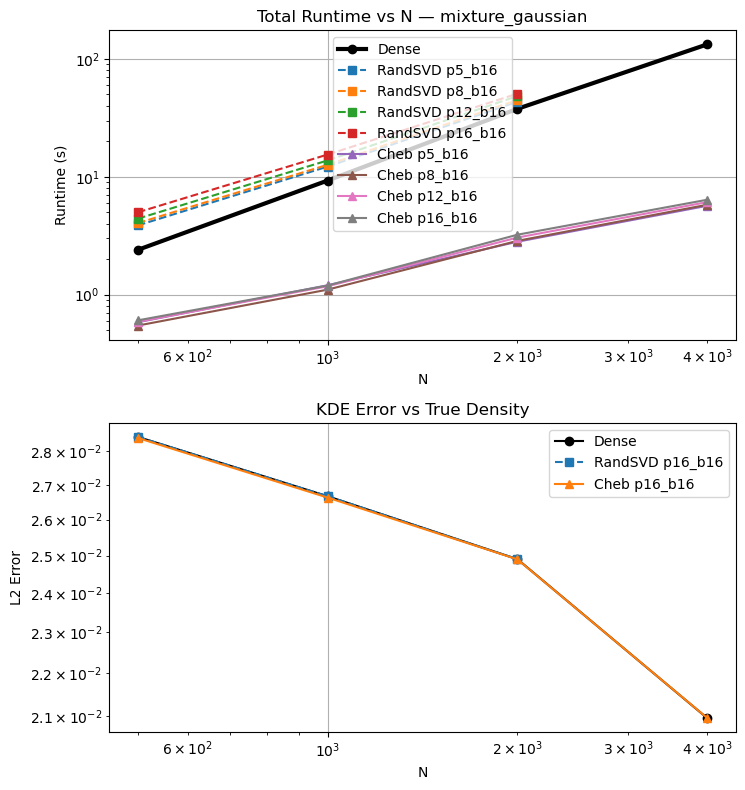

Creating gradient descent scaling plot...


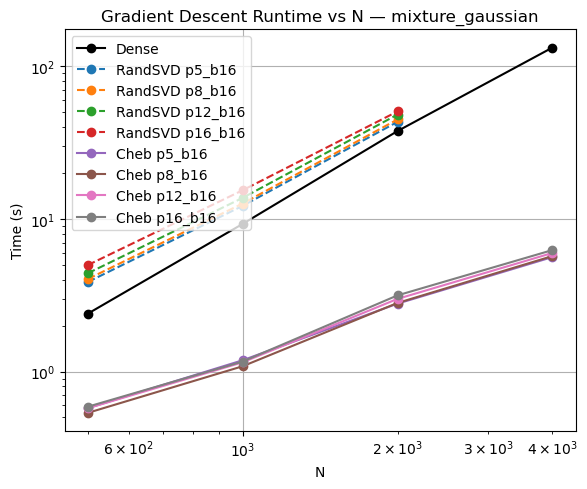

Creating final KDE distribution comparison...


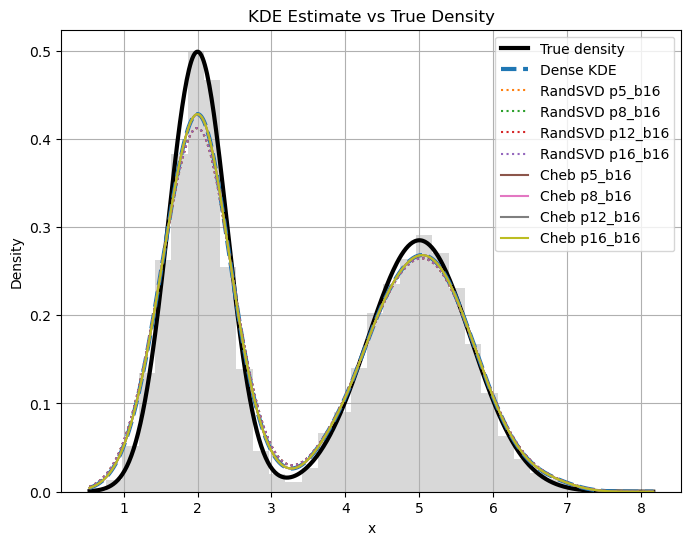

Creating speedup plots...
Saved: speedup_bar.png


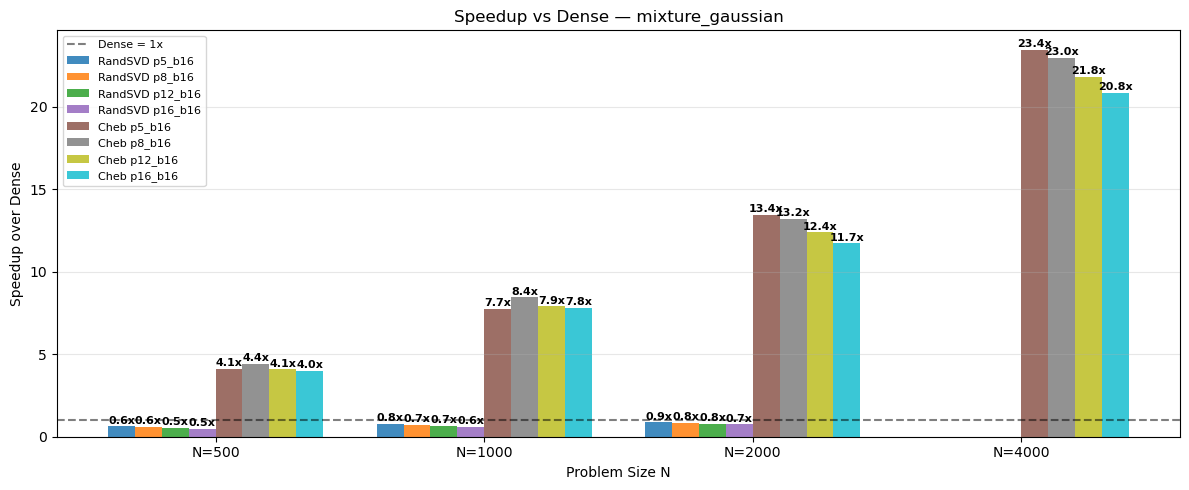

Creating error vs rank plot...


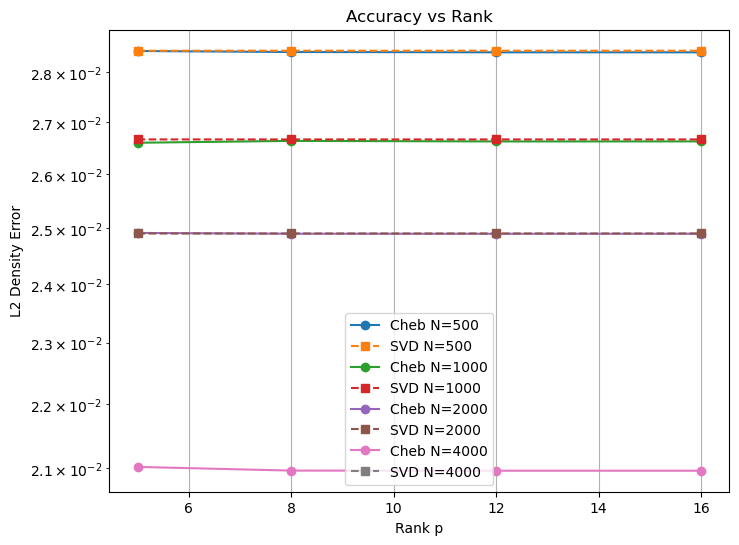

Printing timing breakdown...

TIMING BREAKDOWN

MIXTURE_GAUSSIAN
N      Method                   Total   Build      GD   Speedup   J_final
----------------------------------------------------------------------
500    DENSE                    2.395s       -   2.395s     1.00x   0.11891
500    RandSVD_p5_b16           3.863s   0.000s   3.863s     0.62x   0.11891
500    RandSVD_p8_b16           4.040s   0.000s   4.040s     0.59x   0.11891
500    RandSVD_p12_b16          4.406s   0.000s   4.406s     0.54x   0.11891
500    RandSVD_p16_b16          4.987s   0.000s   4.987s     0.48x   0.11891
500    Cheb_p5_b16              0.582s   0.007s   0.576s     4.11x   0.13167
500    Cheb_p8_b16              0.546s   0.009s   0.536s     4.39x   0.13086
500    Cheb_p12_b16             0.587s   0.012s   0.575s     4.08x   0.13079
500    Cheb_p16_b16             0.604s   0.016s   0.588s     3.97x   0.13079
1000   DENSE                    9.284s       -   9.284s     1.00x   0.19309
1000   RandSVD_p5_b16 

In [55]:
run_all_plots(results, N_values)

In [56]:
def run_largeN_cheb_test(N_values=[1000,2000,4000,8000,16000], p=8):

    results = {}

    for N in N_values:

        print(f"\nRunning CHEB_HODLR KDE for N = {N}")

        # generate data (same as your earlier experiments)
        x = generate_mixture_gaussian_data(N)
        x = np.sort(x)

        # evaluation points and targets
        z = (x[:-1] + x[1:]) / 2
        T = np.arange(1, len(z)+1) / N

        h_opt, info = solve_kde_enhanced(
            x, z, T,
            method='CHEB_HODLR',
            p=p,
            verbose=False
        )

        results[N] = info

        print(f"time = {info['total_time']:.3f}s")

    return results

In [57]:
def plot_cheb_scaling(results):

    Ns = sorted(results.keys())
    times = [results[n]['total_time'] for n in Ns]

    plt.figure(figsize=(7,5))
    plt.plot(Ns, times, marker='o', linewidth=2)

    plt.xlabel("N (data size)")
    plt.ylabel("Time (seconds)")
    plt.title("Chebyshev-HODLR KDE Time vs N")
    plt.grid(True)

    plt.show()

In [58]:
def plot_cheb_scaling_loglog(results):

    import numpy as np

    Ns = np.array(sorted(results.keys()))
    times = np.array([results[n]['total_time'] for n in Ns])

    plt.figure(figsize=(7,5))

    # Actual timing
    plt.loglog(Ns, times, marker='o', linewidth=2, label="Cheb-HODLR KDE")

    # O(N) reference
    ref_on = times[0] * (Ns / Ns[0])
    plt.loglog(Ns, ref_on, '--', label="O(N)")

    # O(N log N) reference
    ref_nlogn = times[0] * (Ns*np.log(Ns)) / (Ns[0]*np.log(Ns[0]))
    plt.loglog(Ns, ref_nlogn, '--', label="O(N log N)")

    plt.xlabel("N (data size)")
    plt.ylabel("Time (seconds)")
    plt.title("Chebyshev-HODLR KDE Scaling (log-log)")
    plt.grid(True, which="both")
    plt.legend()

    plt.show()


Running CHEB_HODLR KDE for N = 1000
time = 1.115s

Running CHEB_HODLR KDE for N = 2000
time = 2.938s

Running CHEB_HODLR KDE for N = 4000
time = 6.005s

Running CHEB_HODLR KDE for N = 8000
time = 11.896s

Running CHEB_HODLR KDE for N = 16000
time = 25.570s


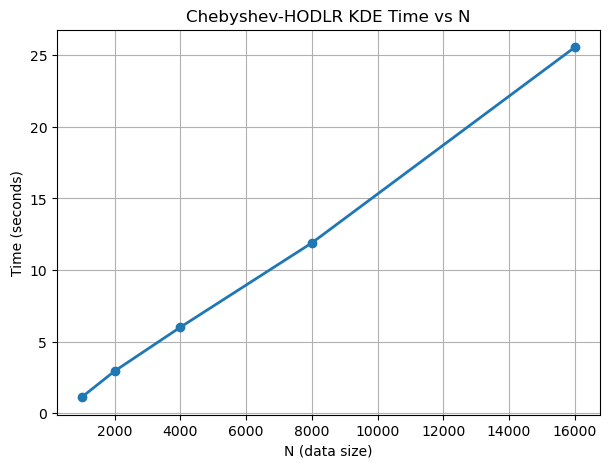

In [59]:
N_values = [1000, 2000, 4000, 8000, 16000]

cheb_results = run_largeN_cheb_test(N_values)

plot_cheb_scaling(cheb_results)

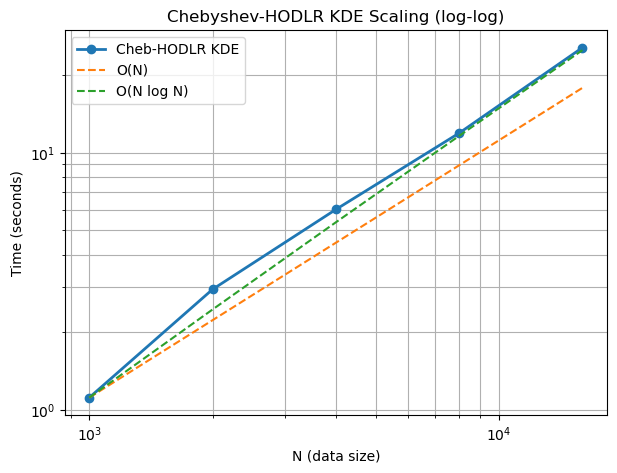

In [60]:
plot_cheb_scaling_loglog(cheb_results)